# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns





## 2. Завантаження даних
Завантажте файл двома способами.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [6]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv('house_price_regression_dataset.csv')




Saving house_price_regression_dataset.csv to house_price_regression_dataset.csv


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prokshitha/home-value-insights")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'home-value-insights' dataset.
Path to dataset files: /kaggle/input/home-value-insights


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [24]:
display(df.head())
df.info()




,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [23]:
df.duplicated().sum()




np.int64(0)

### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [22]:
df.isnull().sum()




,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [21]:
df.describe()




,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [20]:
df['Neighborhood_Quality'].value_counts()




,count
Neighborhood_Quality,
10,123
5,109
2,105
7,102
6,101
4,99
8,97
1,91
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

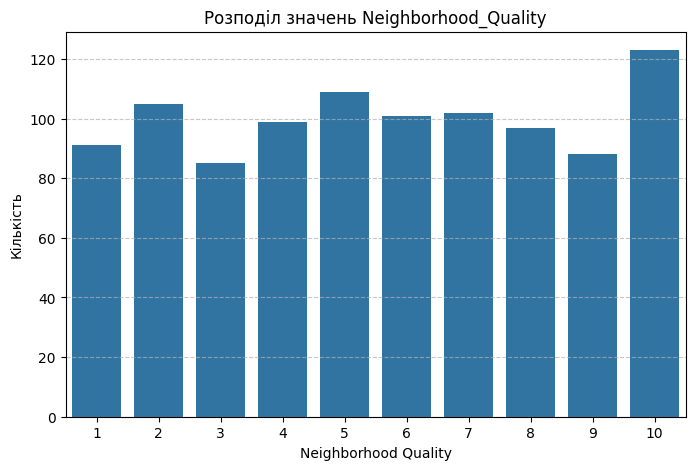

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Neighborhood_Quality')
plt.title('Розподіл значень Neighborhood_Quality')
plt.xlabel('Neighborhood Quality')
plt.ylabel('Кількість')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [18]:
df['Num_Bathrooms'].value_counts()




,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

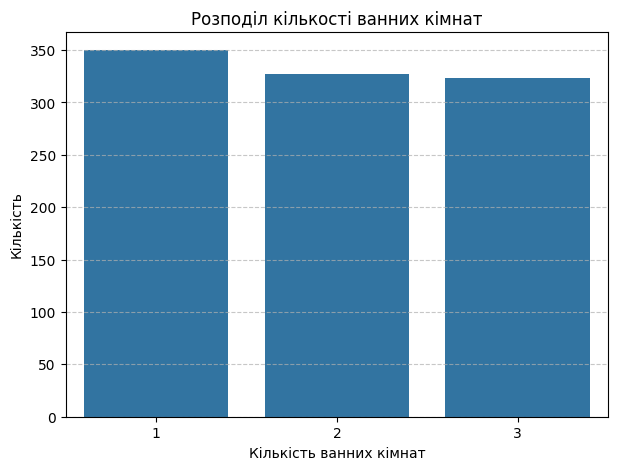

In [17]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Num_Bathrooms')
plt.title('Розподіл кількості ванних кімнат')
plt.xlabel('Кількість ванних кімнат')
plt.ylabel('Кількість')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()





### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

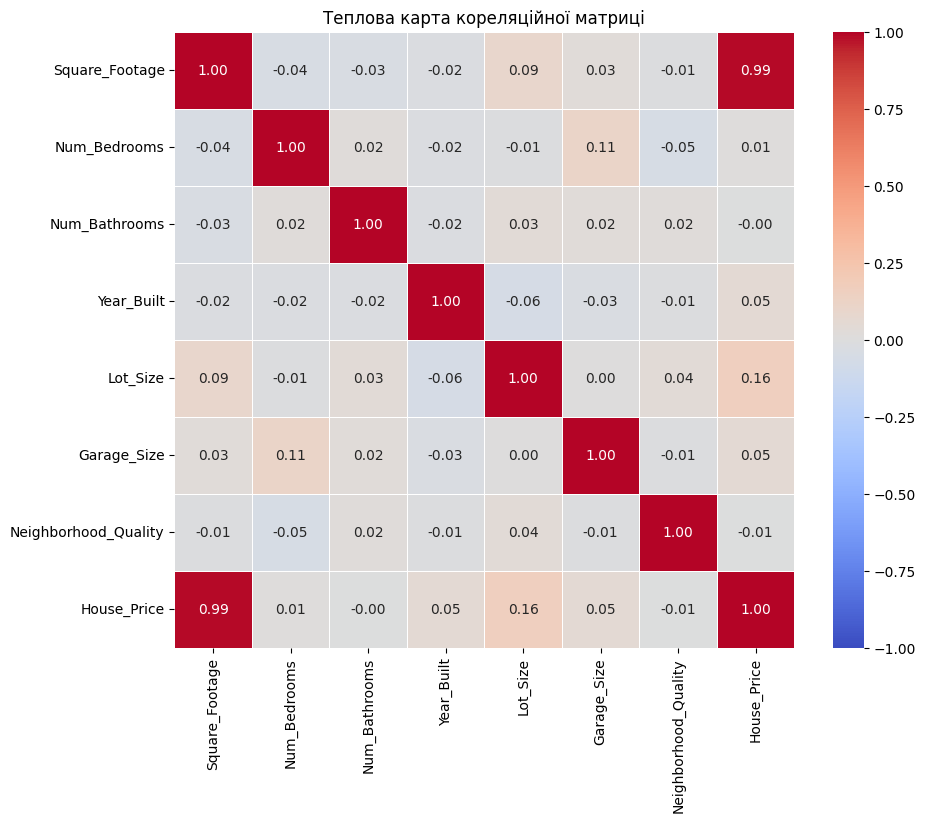

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Теплова карта кореляційної матриці')
plt.show()





### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [15]:
df.corr()['House_Price'].sort_values(ascending=False)




,House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score





### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [37]:
X = df.drop(columns=['House_Price'])
y = df['House_Price']




### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)





### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Ridge())
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Lasso())
    ]),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}





### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [39]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results.append({
        'Model': name,
        'R2': r2,
        'MAE': mae,
        'MSE': mse
    })

results_df = pd.DataFrame(results)
results_df




,Model,R2,MAE,MSE
0,Linear Regression,0.998426,8174.583600,1.014348e+08
1,Ridge,0.998410,8241.586911,1.024810e+08
2,Lasso,0.998426,8174.748374,1.014366e+08
3,Random Forest Regressor,0.993886,16114.289644,3.941317e+08
4,Gradient Boosting Regressor,0.996510,12305.217615,2.249656e+08


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

min_val = y_test.min()
max_val = y_test.max()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)

    # Фактичні vs Прогнозовані значення
    axes[i].scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)

    # Лінія ідеального прогнозу (y = x)
    axes[i].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ідеальний прогноз')

    axes[i].set_title(name, fontsize=12)
    axes[i].set_xlabel('Фактичні значення (Actual)')
    axes[i].set_ylabel('Прогнозовані значення (Predicted)')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.6)

# Приховуємо зайвий шостий підграфік
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()





## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Сітка гіперпараметрів для дослідження
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_features': [1.0, 'sqrt', 'log2'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Базова модель
rf = RandomForestRegressor(random_state=42)

# Налаштування GridSearchCV (крос-валідація 5 фолдів, оптимізація за R²)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Навчання пошуку по сітці
grid_search.fit(X_train, y_train)

# Виведення найкращих параметрів та результату
print(f"Найкращі параметри: {grid_search.best_params_}")
print(f"Найкращий R² на крос-валідації: {grid_search.best_score_:.4f}")

Найкращі параметри: {'max_depth': None, 'max_features': 1.0, 'min_samples_split': 2, 'n_estimators': 150}
Найкращий R² на крос-валідації: 0.9920


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [31]:
# Отримання найкращої моделі з GridSearchCV
best_rf = grid_search.best_estimator_

# Якщо потрібно створити модель явно через знайдені параметри:
# best_rf = RandomForestRegressor(**grid_search.best_params_, random_state=42)
# best_rf.fit(X_train, y_train)

# Прогноз на тестовій вибірці
y_pred_best_rf = best_rf.predict(X_test)

# Розрахунок метрик якості
r2_best_rf = r2_score(y_test, y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)

print("Результати оптимізованої моделі Random Forest:")
print(f"R²:  {r2_best_rf:.4f}")
print(f"MAE: {mae_best_rf:.2f}")
print(f"MSE: {mse_best_rf:.2f}")




Результати оптимізованої моделі Random Forest:
R²:  0.9940
MAE: 15940.72
MSE: 386028572.94


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [40]:
# Отримання метрик базової моделі з results_df
base_rf_row = results_df[results_df['Model'] == 'Random Forest Regressor'].iloc[0]

# Формування порівняльної таблиці
comparison_df = pd.DataFrame([
    {
        'Модель': 'Random Forest (Базова)',
        'R2': base_rf_row['R2'],
        'MAE': base_rf_row['MAE'],
        'MSE': base_rf_row['MSE']
    },
    {
        'Модель': 'Random Forest (Оптимізована)',
        'R2': r2_best_rf,
        'MAE': mae_best_rf,
        'MSE': mse_best_rf
    }
])

display(comparison_df)




,Модель,R2,MAE,MSE
0,Random Forest (Базова),0.993886,16114.289644,3.941317e+08
1,Random Forest (Оптимізована),0.994011,15940.719494,3.860286e+08


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:** Після підбору гіперпараметрів якість моделі майже не змінилася: метрики MAE та MSE зменшилися мінімально, а $R^2$ залишився на рівні близько 0.994. Використовувати оптимізований Random Forest практично недоцільно, оскільки тюнінг потребує значних обчислювальних ресурсів, тоді як прості лінійні моделі на цих даних показують кращу точність ($R^2 \approx 0.998$, суттєво нижчі MAE та MSE) і навчаються майже миттєво.

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [41]:
# Отримання прогнозів лінійної регресії
y_pred_lr = models['Linear Regression'].predict(X_test)

# Створення таблиці
predictions_df = pd.DataFrame({
    'Фактична ціна': y_test,
    'Прогнозована ціна': y_pred_lr
})

# Розрахунок похибки у відсотках (MAPE-стиль для кожного рядка)
predictions_df['Похибка (%)'] = (
    abs(predictions_df['Фактична ціна'] - predictions_df['Прогнозована ціна'])
    / predictions_df['Фактична ціна']
) * 100

# Виведення 10 випадкових рядків
predictions_df.sample(10, random_state=42)





,Фактична ціна,Прогнозована ціна,Похибка (%)
436,1.068538e+06,1.059729e+06,0.824406
899,1.943537e+05,1.878686e+05,3.336793
346,2.702306e+05,2.797158e+05,3.510031
60,9.860069e+05,9.819493e+05,0.411517
867,9.533397e+05,9.573829e+05,0.424111
432,9.145557e+05,9.097643e+05,0.523912
543,7.461677e+05,7.424691e+05,0.495678
361,6.467663e+05,6.544456e+05,1.187332
486,5.233231e+05,5.246054e+05,0.245045
277,1.008539e+06,1.011344e+06,0.278073


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:** У роботі побудовано п’ять моделей: Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting. Найкращі результати продемонструвала Linear Regression ($R^2 \approx 0.998$, найменші помилки MAE та MSE) через лінійний характер даних. Підбір гіперпараметрів для Random Forest дав мінімальний ефект ($R^2 \approx 0.994$) і не виправдав витрачених обчислювальних ресурсів. Отримані прогнози на тестовій вибірці є високоточними ($R^2 > 0.99$, відхилення мінімальні). На якість прогнозування вартості нерухомості на практиці впливають площа, локація, стан і рік побудови будинку, інфраструктура, а також відсутність шумів і викидів у навчальних даних.